In [2]:
import json
import numpy as np
import ast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from metrics_clean import compute_zadu_metrics
from utils import create_ground_truth_dst, get_returns

## Load all the data

### Ground Truth and Returns embeddings

In [3]:
all_gt_emb = []
all_returns = []
for i in range(6):
    path = f"trajectories/left_right_dst/left_right_dst_{i}.json"
    emb_gt = create_ground_truth_dst(path)
    returns = get_returns(path)
    all_gt_emb.append(emb_gt)
    all_returns.append(returns)

all_gt_emb = np.array(all_gt_emb)
all_returns = np.array(all_returns)

all_gt_emb_concave = []
all_returns_concave = []
for i in range(10):
    path=f"trajectories/dst_concave/dst_{i}.json"
    emb_gt = create_ground_truth_dst(path)
    returns = get_returns(path)
    all_gt_emb_concave.append(emb_gt)
    all_returns_concave.append(returns)

all_gt_emb_concave = np.array(all_gt_emb_concave)
all_returns_concave = np.array(all_returns_concave)

dim=["3D","4D"]
for dim_i in dim:
    all_t_emb = []
    all_returns = []
    path=f'trajectories/dst_concave/dst_concave_{dim_i}_embeddings.json'
    with open(path, "r") as f:
        embedding = json.load(f)
    for policy in embedding:
        returns = np.array(ast.literal_eval(policy['Return']))
        all_returns.append(returns)
        t_emb = np.array(policy['T_Embedding'])
        all_t_emb.append(t_emb)
    if dim_i == "3D":
        all_t_emb_3D_concave = np.array(all_t_emb)
    else:
        all_t_emb_4D_concave = np.array(all_t_emb)   
    all_returns_concave = np.array(all_returns)
for dim_i in dim:
    all_t_emb = []
    all_returns = []
    path=f'trajectories/left_right_dst/left_right_dst_{dim_i}_embeddings.json'
    with open(path, "r") as f:
        embedding = json.load(f)
    all_returns = []
    for policy in embedding:
        returns = np.array(ast.literal_eval(policy['Return']))
        all_returns.append(returns)
        t_emb = np.array(policy['T_Embedding'])
        all_t_emb.append(t_emb)
    if dim_i == "3D":
        all_t_emb_3D = np.array(all_t_emb)
    else:
        all_t_emb_4D = np.array(all_t_emb)
    all_returns = np.array(all_returns)

print(f"Ground truth data loaded successfully:")
print(f" Ground truth embeddings Left right:  all_gt_emb shape: {all_gt_emb.shape}")
print(f" Ground truth returns Left right:  all_returns shape: {all_returns.shape}")
print(f" Ground truth embeddings Concave:  all_gt_emb_concave shape: {all_gt_emb_concave.shape}")
print(f" Ground truth returns Concave:  all_returns_concave shape: {all_returns_concave.shape}")
print(f"Transformer embeddings loaded successfully:")
print(f" Transformer embeddings Left right 3D:  all_t_emb_3D shape: {all_t_emb_3D.shape}")
print(f" Transformer embeddings Left right 4D:  all_t_emb_4D shape: {all_t_emb_4D.shape}")
print(f" Transformer embeddings Concave 3D:  all_t_emb_3D_concave shape: {all_t_emb_3D_concave.shape}")
print(f" Transformer embeddings Concave 4D:  all_t_emb_4D_concave shape: {all_t_emb_4D_concave.shape}")

Ground truth data loaded successfully:
 Ground truth embeddings Left right:  all_gt_emb shape: (6, 2)
 Ground truth returns Left right:  all_returns shape: (6, 2)
 Ground truth embeddings Concave:  all_gt_emb_concave shape: (10, 2)
 Ground truth returns Concave:  all_returns_concave shape: (10, 2)
Transformer embeddings loaded successfully:
 Transformer embeddings Left right 3D:  all_t_emb_3D shape: (6, 3)
 Transformer embeddings Left right 4D:  all_t_emb_4D shape: (6, 4)
 Transformer embeddings Concave 3D:  all_t_emb_3D_concave shape: (10, 3)
 Transformer embeddings Concave 4D:  all_t_emb_4D_concave shape: (10, 4)


## Trustworthiness and Continuity

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("=== ZADU METRICS COMPUTATION ===")

# 1. Raw metrics
print("\n--- RAW METRICS ---")
print("Left-right: Returns vs GTE:", compute_zadu_metrics(all_returns, all_gt_emb))
print("Concave: Returns vs GTE:", compute_zadu_metrics(all_returns_concave, all_gt_emb_concave))
print("Left-right: Returns vs TE 3D:", compute_zadu_metrics(all_returns, all_t_emb_3D))
print("Concave: Returns vs TE:", compute_zadu_metrics(all_returns_concave, all_t_emb_3D_concave))
print("Left-right: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb, all_t_emb_3D))
print("Concave: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb_concave, all_t_emb_3D_concave))

# 2. Standardized metrics
scaler = StandardScaler()
all_returns_std = scaler.fit_transform(all_returns)
all_returns_concave_std = scaler.fit_transform(all_returns_concave)
all_gt_emb_std = scaler.fit_transform(all_gt_emb)
all_gt_emb_concave_std = scaler.fit_transform(all_gt_emb_concave)
all_t_emb_3D_std = scaler.fit_transform(all_t_emb_3D)
all_t_emb_3D_concave_std = scaler.fit_transform(all_t_emb_3D_concave)

print("\n--- STANDARDIZED METRICS ---")
print("Left-right: Returns vs GTE:", compute_zadu_metrics(all_returns_std, all_gt_emb_std))
print("Concave: Returns vs GTE:", compute_zadu_metrics(all_returns_concave_std, all_gt_emb_concave_std))
print("Left-right: Returns vs TE:", compute_zadu_metrics(all_returns_std, all_t_emb_3D_std))
print("Concave: Returns vs TE:", compute_zadu_metrics(all_returns_concave_std, all_t_emb_3D_concave_std))
print("Left-right: GTE vs TE:", compute_zadu_metrics(all_gt_emb_std, all_t_emb_3D_std))
print("Concave: GTE vs TE:", compute_zadu_metrics(all_gt_emb_concave_std, all_t_emb_3D_concave_std))

# 3. Normalized metrics
scaler = MinMaxScaler()
all_returns_norm = scaler.fit_transform(all_returns)
all_returns_concave_norm = scaler.fit_transform(all_returns_concave)
all_gt_emb_norm = scaler.fit_transform(all_gt_emb)
all_gt_emb_concave_norm = scaler.fit_transform(all_gt_emb_concave)
all_t_emb_3D_norm = scaler.fit_transform(all_t_emb_3D)
all_t_emb_3D_concave_norm = scaler.fit_transform(all_t_emb_3D_concave)

print("\n--- NORMALIZED METRICS ---")
print("Left-right: Returns vs GTE:", compute_zadu_metrics(all_returns_norm, all_gt_emb_norm))
print("Concave: Returns vs GTE:", compute_zadu_metrics(all_returns_concave_norm, all_gt_emb_concave_norm))
print("Left-right: Returns vs TE:", compute_zadu_metrics(all_returns_norm, all_t_emb_3D_norm))
print("Concave: Returns vs TE:", compute_zadu_metrics(all_returns_concave_norm, all_t_emb_3D_concave_norm))
print("Left-right: GTE vs TE:", compute_zadu_metrics(all_gt_emb_norm, all_t_emb_3D_norm))
print("Concave: GTE vs TE:", compute_zadu_metrics(all_gt_emb_concave_norm, all_t_emb_3D_concave_norm))


=== ZADU METRICS COMPUTATION ===

--- RAW METRICS ---
ZADU metrics computed successfully
Left-right: Returns vs GTE: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.5}, {'mrre_false': 0.5897435897435898, 'mrre_missing': 0.5}]
ZADU metrics computed successfully
Concave: Returns vs GTE: [{'trustworthiness': 0.7, 'continuity': 0.6230769230769232}, {'mrre_false': 0.6639999999999999, 'mrre_missing': 0.6239999999999999}]
ZADU metrics computed successfully
Left-right: Returns vs TE 3D: [{'trustworthiness': 0.36666666666666653, 'continuity': 0.5}, {'mrre_false': 0.5641025641025642, 'mrre_missing': 0.47435897435897445}]
ZADU metrics computed successfully
Concave: Returns vs TE: [{'trustworthiness': 0.7692307692307693, 'continuity': 0.9076923076923077}, {'mrre_false': 0.8280000000000001, 'mrre_missing': 0.8960000000000001}]
ZADU metrics computed successfully
Left-right: GTE vs TE 3D: [{'trustworthiness': 0.8666666666666667, 'continuity': 0.9}, {'mrre_false': 0.9102564102564102, 'mrre_mi

### PCA on TE 

In [5]:
pca = PCA(n_components=2)
all_t_emb_concave_2d = pca.fit_transform(all_t_emb_3D_concave)
all_t_emb_2d = pca.fit_transform(all_t_emb_3D)
zadu_metrics_concave_2d = compute_zadu_metrics(all_gt_emb_concave, all_t_emb_concave_2d)
print(f"GTE vs TE Metrics for concave 2D: {zadu_metrics_concave_2d}")
zadu_metrics_ls_2d = compute_zadu_metrics(all_gt_emb, all_t_emb_2d)
print(f"GTE vs TE Metrics for left_right 2D: {zadu_metrics_ls_2d}")

ZADU metrics computed successfully
GTE vs TE Metrics for concave 2D: [{'trustworthiness': 0.6461538461538462, 'continuity': 0.7615384615384615}, {'mrre_false': 0.6439999999999999, 'mrre_missing': 0.72}]
ZADU metrics computed successfully
GTE vs TE Metrics for left_right 2D: [{'trustworthiness': 0.8666666666666667, 'continuity': 0.9}, {'mrre_false': 0.9102564102564102, 'mrre_missing': 0.923076923076923}]


### Visualize embeddings

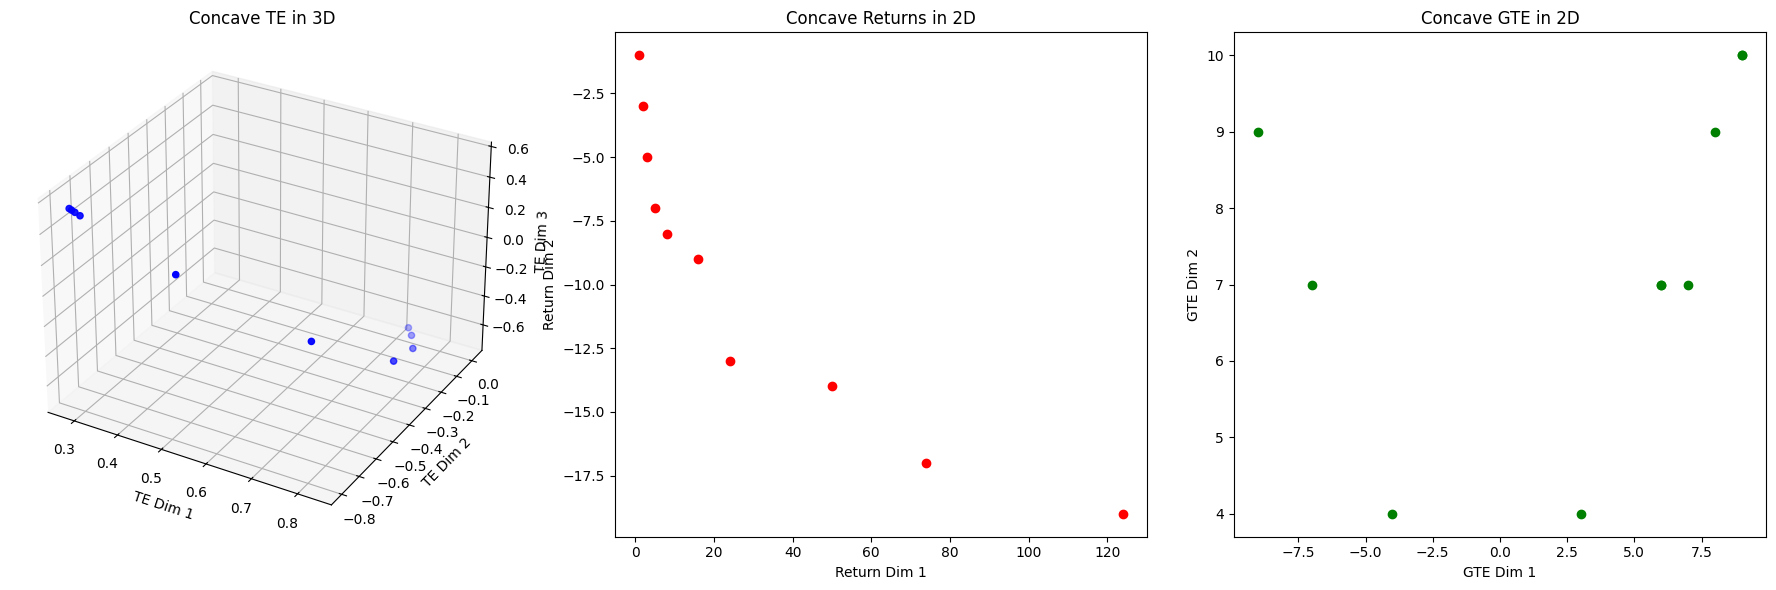

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))

# 3D scatter for transformer embeddings
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(all_t_emb_3D_concave[:,0], all_t_emb_3D_concave[:,1], all_t_emb_3D_concave[:,2], c='b', marker='o')
ax1.set_title('Concave TE in 3D')
ax1.set_xlabel('TE Dim 1')
ax1.set_ylabel('TE Dim 2')
ax1.set_zlabel('TE Dim 3')

# 2D scatter for returns
ax2 = fig.add_subplot(132)
ax2.scatter(all_returns_concave[:,0], all_returns_concave[:,1], c='r', marker='o')
ax2.set_title('Concave Returns in 2D')
ax2.set_xlabel('Return Dim 1')
ax2.set_ylabel('Return Dim 2')

# 2D scatter for ground truth embeddings
ax3 = fig.add_subplot(133)
ax3.scatter(all_gt_emb_concave[:,0], all_gt_emb_concave[:,1], c='g', marker='o')
ax3.set_title('Concave GTE in 2D')
ax3.set_xlabel('GTE Dim 1')
ax3.set_ylabel('GTE Dim 2')

plt.tight_layout()
plt.show()

## Lipschitz Histograms


Lipschitz constant for policy 0 ([124. -19.], [ 9 10]) to 1 ([120. -18.], [-9  9]): 4.372373160976031, d_obj: 4.123105625617661, d_emb: 18.027756377319946
Lipschitz constant for policy 1 ([120. -18.], [-9  9]) to 2 ([ 25. -14.], [-7  7]): 0.02974656063656232, d_obj: 95.08417323613851, d_emb: 2.8284271247461903
Lipschitz constant for policy 2 ([ 25. -14.], [-7  7]) to 3 ([ 24. -13.], [6 7]): 9.192388155425117, d_obj: 1.4142135623730951, d_emb: 13.0
Lipschitz constant for policy 3 ([ 24. -13.], [6 7]) to 4 ([ 7. -8.], [-4  4]): 0.5891805817928689, d_obj: 17.72004514666935, d_emb: 10.44030650891055
Lipschitz constant for policy 4 ([ 7. -8.], [-4  4]) to 5 ([ 6. -7.], [3 4]): 4.949747468305833, d_obj: 1.4142135623730951, d_emb: 7.0
Lipschitz constant for policy 0 ([124. -19.], [ 9 10]) to 1 ([ 74. -17.], [8 9]): 0.028261670947211076, d_obj: 50.039984012787215, d_emb: 1.4142135623730951
Lipschitz constant for policy 1 ([ 74. -17.], [8 9]) to 2 ([ 50. -14.], [7 7]): 0.09245003270420486, d_ob

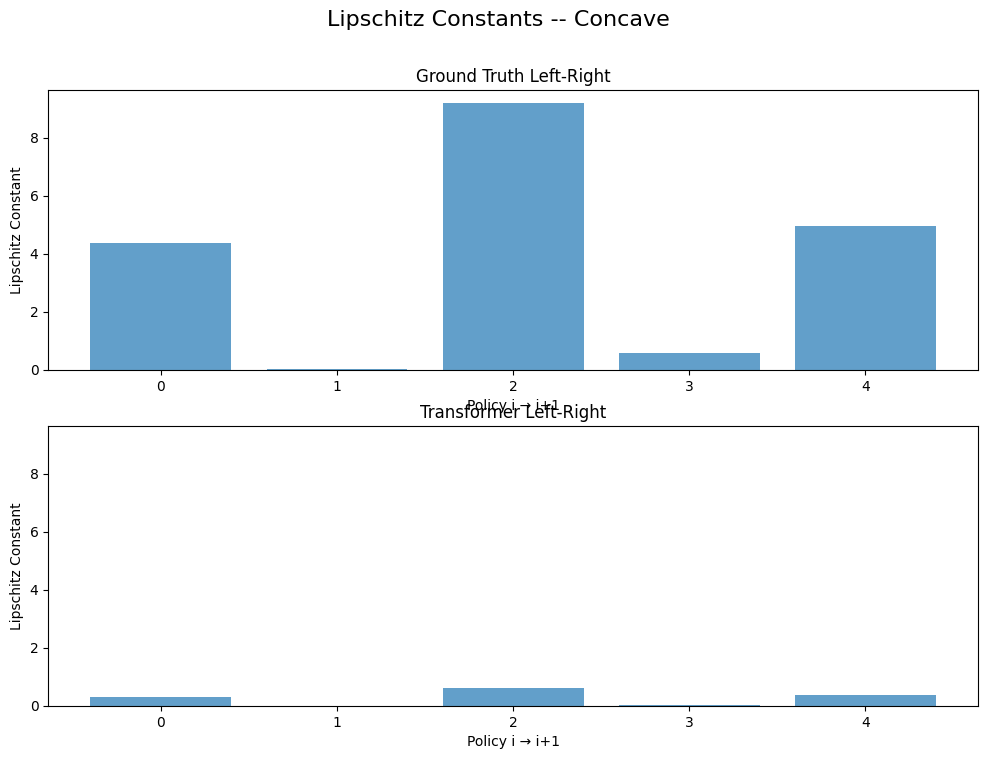

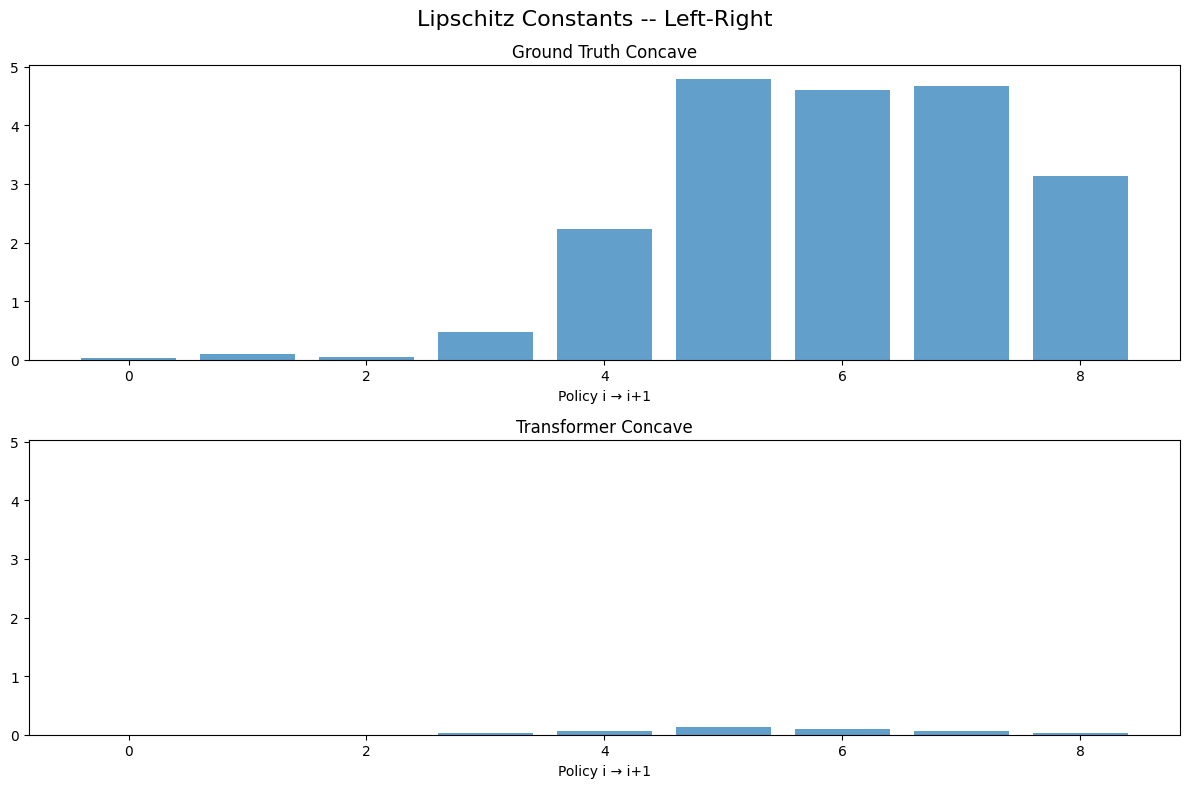

In [ ]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns

# Compute Lipschitz constants
def compute_lipschitz_constants(pareto_frontier: np.ndarray, embeddings: np.ndarray) -> np.ndarray:
    """
    Compute pairwise Lipschitz constants between consecutive points
    in the Pareto frontier and embedding space.

    Args:
        pareto_frontier: (n_points, d_obj) array of objective values
        embeddings: (n_points, d_emb) array of embeddings

    Returns:
        lipschitz_constants: (n_points-1,) array of Lipschitz constants
    """
    # Lexicographic sort: np.lexsort expects keys in reverse order
    sort_idx = np.lexsort(pareto_frontier.T)
    sorted_pf = pareto_frontier[sort_idx]
    sorted_emb = embeddings[sort_idx]

    lipschitz_constants = []
    for i in range(len(sorted_pf) - 1):
        d_obj = np.linalg.norm(sorted_pf[i+1] - sorted_pf[i])
        d_emb = np.linalg.norm(sorted_emb[i+1] - sorted_emb[i])
        lipschitz_constants.append(d_emb / d_obj)

        print(f"Lipschitz constant for policy {i} ({sorted_pf[i]}, {sorted_emb[i]}) to {i+1} ({sorted_pf[i+1]}, {sorted_emb[i+1]}): {lipschitz_constants[-1]}, d_obj: {d_obj}, d_emb: {d_emb}")

    return np.array(lipschitz_constants)



lipschitz_constants_gt = compute_lipschitz_constants(pareto_frontier=all_returns, embeddings=all_gt_emb)
lipschitz_constants_gt_concave = compute_lipschitz_constants(pareto_frontier=all_returns_concave, embeddings=all_gt_emb_concave)

lipschitz_constants_t = compute_lipschitz_constants(pareto_frontier=all_returns, embeddings=all_t_emb_3D)
lipschitz_constants_t_concave = compute_lipschitz_constants(pareto_frontier=all_returns_concave, embeddings=all_t_emb_3D_concave)

print("Concave front", all_returns_concave)
print("Left-Right front", all_returns)
print(f"Lipschitz constants Left-Right: {lipschitz_constants_gt}")
print(f"Lipschitz constants Concave: {lipschitz_constants_gt_concave}")
print(f"Lipschitz constants Transformer Left-Right: {lipschitz_constants_t}")
print(f"Lipschitz constants Transformer Concave: {lipschitz_constants_t_concave}")

# Create 2x1 grid with shared y-axis
fig, axs = plt.subplots(2, figsize=(12, 8))
fig2, axs2 = plt.subplots(2, figsize=(12, 8))
fig.suptitle("Lipschitz Constants -- Concave", fontsize=16)
fig2.suptitle("Lipschitz Constants -- Left-Right", fontsize=16)

# --- Row 1: Ground Truth ---
axs[0].bar(np.arange(len(lipschitz_constants_gt)), lipschitz_constants_gt, alpha=0.7)
axs[0].set_title("Ground Truth Left-Right")
axs[0].set_ylabel("Lipschitz Constant")
axs[0].set_xlabel("Policy i → i+1")

axs[1].bar(np.arange(len(lipschitz_constants_t)), lipschitz_constants_t, alpha=0.7)
axs[1].set_title("Transformer Left-Right")
axs[1].set_ylabel("Lipschitz Constant")
axs[1].set_xlabel("Policy i → i+1")
plt.tight_layout()

# --- Row 2: Transformer ---

axs2[0].bar(np.arange(len(lipschitz_constants_gt_concave)), lipschitz_constants_gt_concave, alpha=0.7)
axs2[0].set_title("Ground Truth Concave")
axs2[0].set_xlabel("Policy i → i+1")

axs2[1].bar(np.arange(len(lipschitz_constants_t_concave)), lipschitz_constants_t_concave, alpha=0.7)
axs2[1].set_title("Transformer Concave")
axs2[1].set_xlabel("Policy i → i+1")

plt.tight_layout()  # leave space for suptitle
plt.show()


